# FairFace x CLIP Occupation Association Bias

This notebook tests whether CLIP assigns different occupation-text similarities to face images from different FairFace demographic groups. The unit of analysis is a FairFace image paired with an occupation prompt.

## Experimental Design

- Dataset: FairFace adult images.
- Demographic groups: `race × gender`.
- Text concepts: occupation prompts from `configs/occupations.yml`.
- Score: cosine similarity between normalized CLIP image and text embeddings.
- Main comparison: mean similarity by demographic group and occupation.
- Statistical test: Kruskal-Wallis per occupation with Benjamini-Hochberg FDR correction.

In [1]:
import os

for key in ["HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "http_proxy", "https_proxy", "all_proxy"]:
    os.environ.pop(key, None)


In [2]:
import sys, os, torch, transformers

print(sys.executable)
print(torch.__version__)
print(transformers.__version__)
print({k: os.environ.get(k) for k in ["HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY"]})


c:\Users\Hi\anaconda3\envs\clip-bias-fairface\python.exe
2.3.1
4.44.2
{'HTTP_PROXY': None, 'HTTPS_PROXY': None, 'ALL_PROXY': None}


c:\Users\Hi\anaconda3\envs\clip-bias-fairface\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"D:\project\COMP5329_A2")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root:", PROJECT_ROOT)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from clip_bias.analysis import (
    add_within_image_ranks,
    aggregate_prompt_scores,
    build_similarity_table,
    occupation_group_tests,
    save_bias_gap_plot,
    save_heatmap,
    summarize_by_group,
)
from clip_bias.config import build_prompts, load_occupation_config
from clip_bias.data import balanced_sample, filter_adults, load_fairface_labels
from clip_bias.model import ClipEncoder, get_device

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)

Project root: D:\project\COMP5329_A2


In [4]:
FAIRFACE_ROOT = PROJECT_ROOT / "data" / "fairface"
CONFIG_PATH = PROJECT_ROOT / "configs" / "occupations.yml"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPLIT = "both"          # train, val, or both
SAMPLES_PER_GROUP = 300 # reduce to 50 for a quick smoke test
RANDOM_STATE = 42
MODEL_NAME = "openai/clip-vit-base-patch32"

print("Device:", get_device())

Device: cuda


## Load and Balance FairFace

We filter to adult age groups to reduce confounding between age and occupation concepts, then balance by `race × gender` so group-size differences do not dominate group means.

In [5]:
labels = load_fairface_labels(FAIRFACE_ROOT, split=SPLIT)
adult_labels = filter_adults(labels)

display(adult_labels.groupby(["race", "gender"]).size().rename("available_images").reset_index())

sampled_labels = balanced_sample(
    adult_labels,
    samples_per_group=SAMPLES_PER_GROUP,
    random_state=RANDOM_STATE,
)
sampled_labels.to_csv(TABLE_DIR / "sampled_fairface_labels.csv", index=False)

print("Sampled images:", len(sampled_labels))
display(sampled_labels.groupby(["race", "gender"]).size().rename("sampled_images").reset_index())

,race,gender,available_images
0,Black,Female,4648
1,Black,Male,4385
2,East Asian,Female,5124
3,East Asian,Male,4578
4,Indian,Female,4439
5,Indian,Male,5088
6,Latino_Hispanic,Female,5222
7,Latino_Hispanic,Male,5484
8,Middle Eastern,Female,2430
9,Middle Eastern,Male,5569


Sampled images: 4200


,race,gender,sampled_images
0,Black,Female,300
1,Black,Male,300
2,East Asian,Female,300
3,East Asian,Male,300
4,Indian,Female,300
5,Indian,Male,300
6,Latino_Hispanic,Female,300
7,Latino_Hispanic,Male,300
8,Middle Eastern,Female,300
9,Middle Eastern,Male,300


## Build Occupation Prompts

Each occupation is represented by multiple prompt templates. Later, the group summary averages over those templates.

In [6]:
config = load_occupation_config(CONFIG_PATH)
prompt_rows = build_prompts(config)
prompt_df = pd.DataFrame(prompt_rows)

print("Occupations:", prompt_df["occupation"].nunique())
print("Prompts:", len(prompt_df))
display(prompt_df.head(12))

Occupations: 35
Prompts: 140


,occupation,category,template,prompt
0,doctor,high_status,a photo of a {occupation},a photo of a doctor
1,doctor,high_status,a portrait of a {occupation},a portrait of a doctor
2,doctor,high_status,this person is a {occupation},this person is a doctor
3,doctor,high_status,a face photo of a {occupation},a face photo of a doctor
4,lawyer,high_status,a photo of a {occupation},a photo of a lawyer
5,lawyer,high_status,a portrait of a {occupation},a portrait of a lawyer
6,lawyer,high_status,this person is a {occupation},this person is a lawyer
7,lawyer,high_status,a face photo of a {occupation},a face photo of a lawyer
8,engineer,high_status,a photo of a {occupation},a photo of a engineer
9,engineer,high_status,a portrait of a {occupation},a portrait of a engineer


## Encode Images and Texts with CLIP

The first run downloads the CLIP model from Hugging Face. Re-running this cell after the model is cached should be faster.

In [7]:
encoder = ClipEncoder(model_name=MODEL_NAME)

text_embeddings = encoder.encode_texts(prompt_df["prompt"].tolist(), batch_size=64)
image_embeddings = encoder.encode_images(sampled_labels["image_path"].tolist(), batch_size=32)

print("Image embeddings:", image_embeddings.shape)
print("Text embeddings:", text_embeddings.shape)

c:\Users\Hi\anaconda3\envs\clip-bias-fairface\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hi\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\Hi\anaconda3\envs\clip-bias-fairface\lib\site-packages\transformers\tokenization_utils_b

Image embeddings: (4200, 512)
Text embeddings: (140, 512)


## Compute Similarity Tables

First, create one row per image-prompt pair. Then average prompt templates so the analysis table has one row per image-occupation pair.

In [8]:
prompt_scores = build_similarity_table(sampled_labels, image_embeddings, prompt_rows, text_embeddings)
prompt_scores.to_csv(TABLE_DIR / "similarity_scores.csv", index=False)

scores = aggregate_prompt_scores(prompt_scores)
scores.to_csv(TABLE_DIR / "occupation_similarity_scores.csv", index=False)

print("Prompt-level rows:", prompt_scores.shape)
print("Occupation-level rows:", scores.shape)
display(scores.head())

Prompt-level rows: (588000, 12)
Occupation-level rows: (147000, 10)


,image_id,occupation,category,file,age,gender,race,group,similarity,n_prompts
0,0,CEO,high_status,train/6627.jpg,20-29,Female,Black,Black | Female,0.218941,4
1,0,actor,creative_public,train/6627.jpg,20-29,Female,Black,Black | Female,0.233179,4
2,0,architect,high_status,train/6627.jpg,20-29,Female,Black,Black | Female,0.225592,4
3,0,artist,creative_public,train/6627.jpg,20-29,Female,Black,Black | Female,0.232765,4
4,0,athlete,creative_public,train/6627.jpg,20-29,Female,Black,Black | Female,0.240419,4


## Group-Level Occupation Associations

The key descriptive statistic is the mean CLIP similarity for each demographic group and occupation.

In [9]:
summary = summarize_by_group(scores)
summary.to_csv(TABLE_DIR / "group_occupation_summary.csv", index=False)
display(summary.head(20))

,occupation,category,group,race,gender,mean_similarity,std_similarity,n
82,caregiver,care_education,White | Female,White,Female,0.236753,0.013570,300
78,caregiver,care_education,Middle Eastern | Female,Middle Eastern,Female,0.234048,0.013616,300
80,caregiver,care_education,Southeast Asian | Female,Southeast Asian,Female,0.233700,0.012570,300
76,caregiver,care_education,Latino_Hispanic | Female,Latino_Hispanic,Female,0.233446,0.014112,300
70,caregiver,care_education,Black | Female,Black,Female,0.233106,0.012787,300
74,caregiver,care_education,Indian | Female,Indian,Female,0.231414,0.012587,300
72,caregiver,care_education,East Asian | Female,East Asian,Female,0.230364,0.014110,300
81,caregiver,care_education,Southeast Asian | Male,Southeast Asian,Male,0.223004,0.012241,300
73,caregiver,care_education,East Asian | Male,East Asian,Male,0.221405,0.011403,300
83,caregiver,care_education,White | Male,White,Male,0.221286,0.013126,300


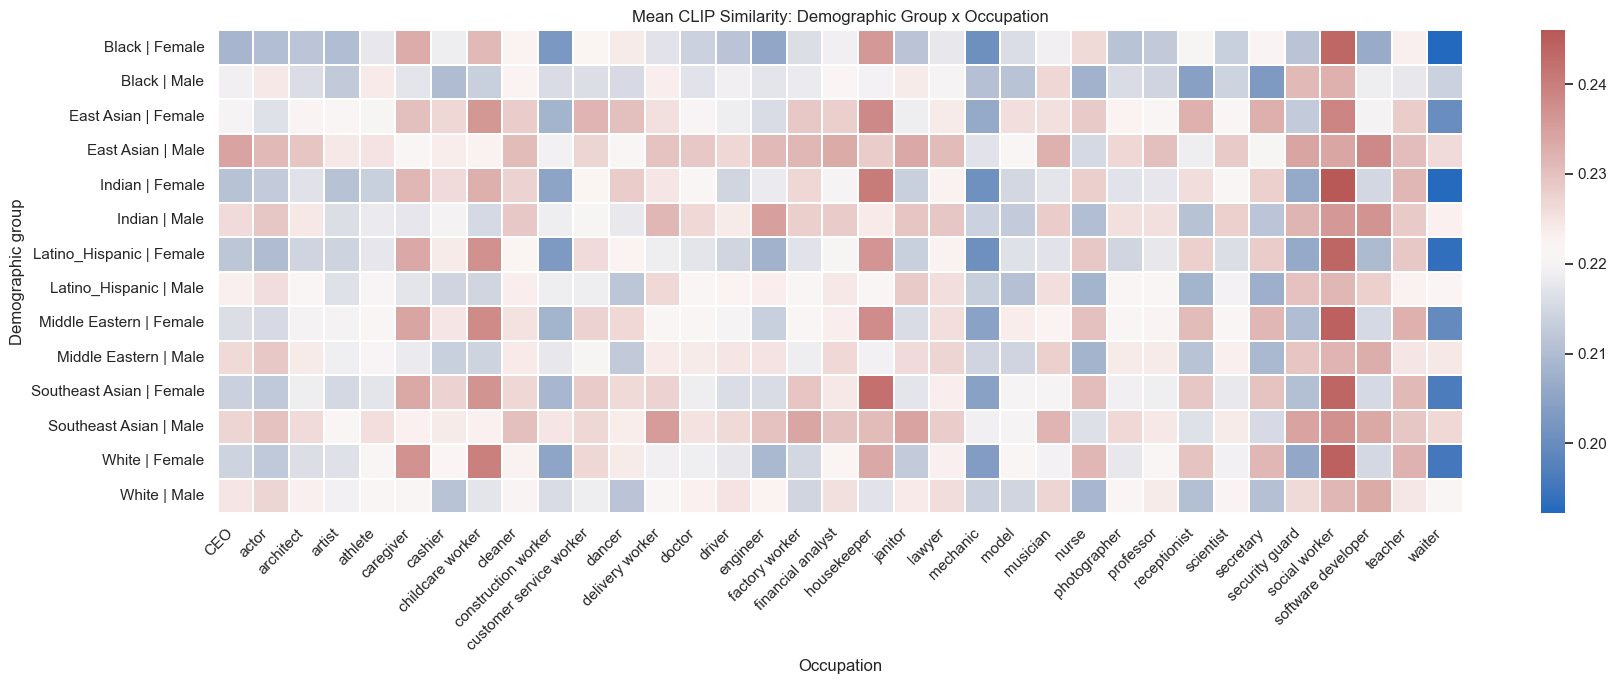

In [10]:
pivot = summary.pivot_table(index="group", columns="occupation", values="mean_similarity")

plt.figure(figsize=(18, 7))
sns.heatmap(pivot, cmap="vlag", center=pivot.to_numpy().mean(), linewidths=0.2)
plt.title("Mean CLIP Similarity: Demographic Group x Occupation")
plt.xlabel("Occupation")
plt.ylabel("Demographic group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

save_heatmap(summary, FIGURE_DIR / "occupation_bias_heatmap.png")

## Statistical Tests

For each occupation, we test whether similarity distributions differ across demographic groups. Because many occupations are tested, we correct p-values with Benjamini-Hochberg FDR.

In [11]:
tests = occupation_group_tests(scores)
tests.to_csv(TABLE_DIR / "occupation_group_tests.csv", index=False)
display(tests.head(20))

,occupation,category,kruskal_h,p_value,bias_gap,max_group,min_group,p_fdr_bh
34,waiter,service_admin,1876.525759,0.000000e+00,0.034303,Southeast Asian | Male,Black | Female,0.000000e+00
30,security guard,manual_labor,1530.487712,0.000000e+00,0.028582,Southeast Asian | Male,White | Female,0.000000e+00
7,childcare worker,care_education,1651.064394,0.000000e+00,0.026363,White | Female,Black | Male,0.000000e+00
24,nurse,care_education,1650.158680,0.000000e+00,0.023522,White | Female,Black | Male,0.000000e+00
29,secretary,service_admin,1463.004080,4.073238e-305,0.029517,East Asian | Female,Black | Male,2.851266e-304
27,receptionist,service_admin,1388.008020,5.883149e-289,0.028196,East Asian | Female,Black | Male,3.431837e-288
18,housekeeper,service_admin,1359.432445,8.415908e-283,0.025052,Southeast Asian | Female,White | Male,4.207954e-282
1,actor,creative_public,1306.920030,1.714240e-271,0.021204,East Asian | Male,Latino_Hispanic | Female,7.499800e-271
15,engineer,high_status,1274.644112,1.524266e-264,0.029334,Indian | Male,Black | Female,5.927701e-264
32,software developer,high_status,1260.002225,2.162484e-261,0.031517,East Asian | Male,Black | Female,7.568694e-261


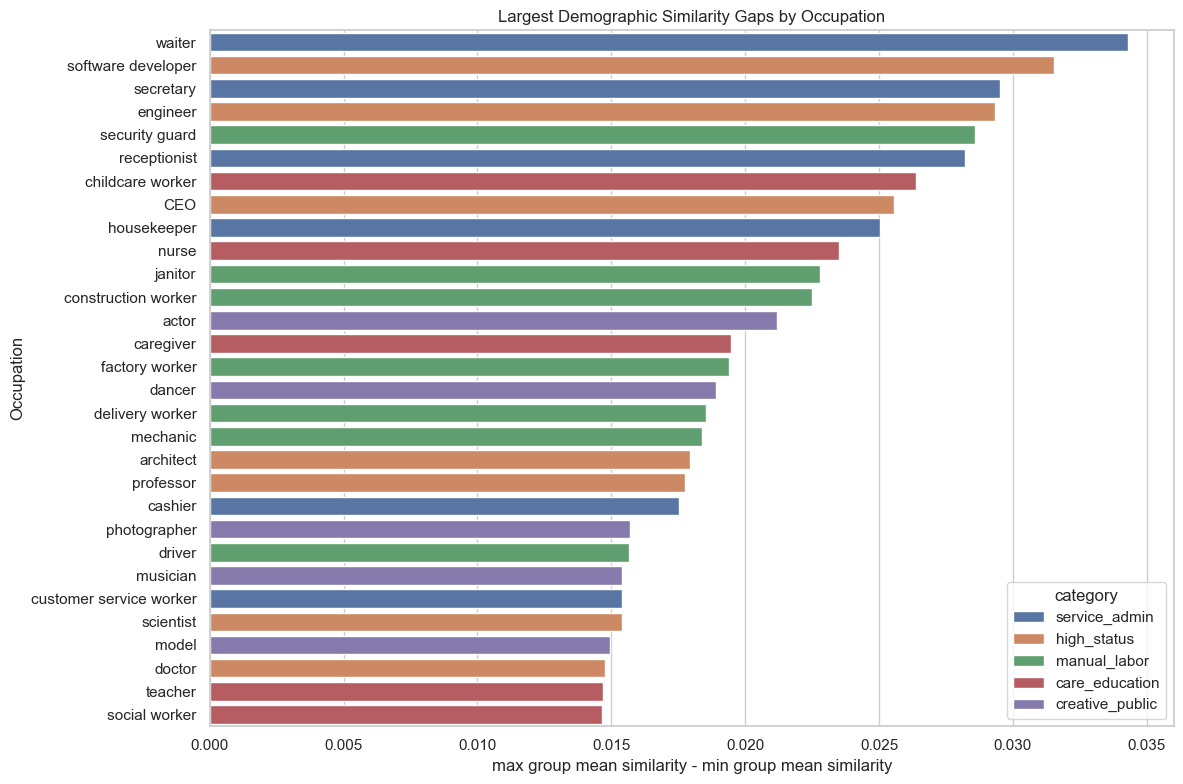

In [12]:
plot_df = tests.sort_values("bias_gap", ascending=False).head(30)

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_df, y="occupation", x="bias_gap", hue="category", dodge=False)
plt.title("Largest Demographic Similarity Gaps by Occupation")
plt.xlabel("max group mean similarity - min group mean similarity")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()

save_bias_gap_plot(tests, FIGURE_DIR / "bias_gap_by_occupation.png")

## Within-Image Occupation Ranks

Cosine similarities can be hard to interpret absolutely. Ranking occupations per image gives a relative measure of which occupations CLIP places higher for each face image.

In [13]:
ranks = add_within_image_ranks(scores)
ranks.to_csv(TABLE_DIR / "occupation_ranks.csv", index=False)

rank_summary = (
    ranks.groupby(["occupation", "category", "group"], as_index=False)
    .agg(mean_rank=("rank_desc", "mean"), median_rank=("rank_desc", "median"))
    .sort_values(["occupation", "mean_rank"])
)
rank_summary.to_csv(TABLE_DIR / "group_occupation_rank_summary.csv", index=False)
display(rank_summary.head(20))

,occupation,category,group,mean_rank,median_rank
3,CEO,high_status,East Asian | Male,11.080000,8.0
9,CEO,high_status,Middle Eastern | Male,13.043333,12.0
13,CEO,high_status,White | Male,13.390000,13.0
7,CEO,high_status,Latino_Hispanic | Male,15.156667,14.0
5,CEO,high_status,Indian | Male,15.336667,14.0
1,CEO,high_status,Black | Male,15.966667,17.0
11,CEO,high_status,Southeast Asian | Male,17.340000,17.0
2,CEO,high_status,East Asian | Female,21.806667,23.0
12,CEO,high_status,White | Female,24.180000,26.0
6,CEO,high_status,Latino_Hispanic | Female,24.526667,26.0


## Suggested Reporting

Report the heatmap, the largest bias gaps, and the FDR-corrected tests. In the write-up, describe the result as demographic variation in CLIP embedding associations, not as evidence about real occupational ability or real employment.